In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('2019-Oct_smartphone_preprocessed_final.csv')

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,is_price_error,hour,day_of_week,day_name,time_segment,is_outlier,is_purchase,is_cart
0,2019-10-01 09:00:04,view,1004237,-1769995873,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,False,9,1,Tuesday,오전 (6-12시),False,0,0
1,2019-10-01 09:00:11,view,1004545,-1769995873,electronics.smartphone,huawei,566.01,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,False,9,1,Tuesday,오전 (6-12시),False,0,0
2,2019-10-01 09:00:11,view,1005011,-1769995873,electronics.smartphone,samsung,900.64,530282093,50a293fb-5940-41b2-baf3-17af0e812101,False,9,1,Tuesday,오전 (6-12시),False,0,0
3,2019-10-01 09:00:19,view,1005135,-1769995873,electronics.smartphone,apple,1747.79,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,False,9,1,Tuesday,오전 (6-12시),False,0,0
4,2019-10-01 09:00:20,view,1003306,-1769995873,electronics.smartphone,apple,588.77,555446831,6ec635da-ea15-4a5d-96b4-c8ca9d38f89f,False,9,1,Tuesday,오전 (6-12시),False,0,0


In [2]:
df = df.sort_values(['user_session', 'event_time']).copy()

In [3]:
grouped = df.groupby(['user_session', 'product_id'])

In [8]:
event_first_time = (
    df
    .groupby(['user_session', 'product_id', 'event_type'])['event_time']
    .min()
    .unstack()
    .reset_index()
)

for col in ['view', 'cart', 'purchase']:
    if col not in event_first_time.columns:
        event_first_time[col] = pd.NaT

# 존재 여부 컬럼 따로 생성
event_first_time['has_view'] = event_first_time['view'].notna()
event_first_time['has_cart'] = event_first_time['cart'].notna()
event_first_time['has_purchase'] = event_first_time['purchase'].notna()

# 순서 검증
event_first_time['view_to_cart'] = (
    event_first_time['has_view'] &
    event_first_time['has_cart'] &
    (event_first_time['view'] < event_first_time['cart'])
)

event_first_time['view_to_cart_to_purchase'] = (
    event_first_time['has_view'] &
    event_first_time['has_cart'] &
    event_first_time['has_purchase'] &
    (event_first_time['view'] < event_first_time['cart']) &
    (event_first_time['cart'] < event_first_time['purchase'])
)

funnel_df = event_first_time[[
    'user_session',
    'product_id',
    'has_view',
    'view_to_cart',
    'view_to_cart_to_purchase'
]].rename(columns={
    'has_view': 'view'
})

In [9]:
funnel_summary = pd.DataFrame({
    'step': ['view', 'view_to_cart', 'view_to_cart_to_purchase'],
    'count': [
        funnel_df['view'].sum(),
        funnel_df['view_to_cart'].sum(),
        funnel_df['view_to_cart_to_purchase'].sum()
    ]
})

funnel_summary['conversion_rate_vs_view'] = (
    funnel_summary['count'] / funnel_summary.loc[0, 'count'] * 100
)

funnel_summary

,step,count,conversion_rate_vs_view
0,view,7058369,100.00000
1,view_to_cart,363163,5.14514
2,view_to_cart_to_purchase,190540,2.69949


In [10]:
view_sessions = funnel_df['view'].sum()
view_to_cart_sessions = funnel_df['view_to_cart'].sum()
view_to_cart_to_purchase_sessions = funnel_df['view_to_cart_to_purchase'].sum()

view_to_cart_rate = view_to_cart_sessions / view_sessions
cart_to_purchase_rate = view_to_cart_to_purchase_sessions / view_to_cart_sessions
total_conversion_rate = view_to_cart_to_purchase_sessions / view_sessions

In [12]:
target_brands = ['samsung', 'apple', 'xiaomi']

df_flow = df[df['brand'].isin(target_brands)].copy()
df_flow = df_flow.sort_values(['user_session', 'event_time'])

flow_df = (
    df_flow[df_flow['event_type'].isin(['view', 'cart', 'purchase'])]
    .groupby(['user_session', 'event_type'])['brand']
    .first()
    .unstack()
    .reset_index()
)

flow_df = flow_df.rename(columns={
    'view': 'view_brand',
    'cart': 'cart_brand',
    'purchase': 'purchase_brand'
})

flow_df.head()

event_type,user_session,cart_brand,purchase_brand,view_brand
0,00000056-a206-40dd-b174-a072550fa38c,NaN,NaN,apple
1,00000083-8816-4d58-a9b8-f52f54186edc,samsung,samsung,samsung
2,000001fd-1f89-45e8-a3ce-fe3218cabfad,samsung,samsung,samsung
3,00000a05-fa4e-4486-b5e8-c8bffa63b422,NaN,NaN,samsung
4,00000aaa-d774-49bc-9c31-0c9f6e1c2f0a,NaN,NaN,xiaomi


In [13]:
def classify_flow(row):
    v = row.get('view_brand')
    c = row.get('cart_brand')
    p = row.get('purchase_brand')

    brands = [x for x in [v, c, p] if pd.notna(x)]

    if pd.isna(v) or pd.isna(p):
        return 'no_purchase_or_no_view'

    if pd.notna(c):
        if v == c == p:
            return 'same_brand'
        elif v != c and c == p:
            return 'view_to_cart_switch'
        elif v == c and c != p:
            return 'cart_to_purchase_switch'
        elif len(set(brands)) == 3:
            return 'multi_brand_exploration'
        else:
            return 'etc'
    else:
        if v == p:
            return 'direct_same_purchase'
        else:
            return 'direct_switch_purchase'

flow_df['pattern'] = flow_df.apply(classify_flow, axis=1)

flow_df['pattern'].value_counts()

pattern
no_purchase_or_no_view     2489618
same_brand                  155753
direct_same_purchase         83564
view_to_cart_switch           6132
direct_switch_purchase        3082
cart_to_purchase_switch        845
etc                            654
multi_brand_exploration         38
Name: count, dtype: int64

In [14]:
flow_df['pattern'].value_counts(normalize=True) * 100

pattern
no_purchase_or_no_view     90.872385
same_brand                  5.685068
direct_same_purchase        3.050131
view_to_cart_switch         0.223821
direct_switch_purchase      0.112495
cart_to_purchase_switch     0.030843
etc                         0.023871
multi_brand_exploration     0.001387
Name: proportion, dtype: float64

view -> cart 변경

In [15]:
vc_switch = flow_df[flow_df['pattern'] == 'view_to_cart_switch'].copy()

vc_matrix = (
    vc_switch.groupby(['view_brand', 'cart_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

vc_matrix

,view_brand,cart_brand,count
0,apple,samsung,1840
3,samsung,xiaomi,1583
2,samsung,apple,1446
5,xiaomi,samsung,757
1,apple,xiaomi,353
4,xiaomi,apple,153


cart -> purchase 변경

In [16]:
cp_switch = flow_df[flow_df['pattern'] == 'cart_to_purchase_switch'].copy()

cp_matrix = (
    cp_switch.groupby(['cart_brand', 'purchase_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

cp_matrix

,cart_brand,purchase_brand,count
0,apple,samsung,294
3,samsung,xiaomi,203
2,samsung,apple,199
5,xiaomi,samsung,102
1,apple,xiaomi,34
4,xiaomi,apple,13


view -> X -> purchase

In [17]:
dp_switch = flow_df[flow_df['pattern'] == 'direct_switch_purchase'].copy()

dp_matrix = (
    dp_switch.groupby(['view_brand', 'purchase_brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

dp_matrix

,view_brand,purchase_brand,count
3,samsung,xiaomi,968
0,apple,samsung,774
2,samsung,apple,715
5,xiaomi,samsung,299
1,apple,xiaomi,228
4,xiaomi,apple,98


같은 브랜드를 구매하는 시간 소요 = 브랜드 관여 정도

In [18]:
# view / purchase 시간 + 브랜드 추출
event_time_df = (
    df[df['event_type'].isin(['view', 'purchase'])]
    .sort_values(['user_session', 'event_time'])
)

event_time_pivot = (
    event_time_df
    .groupby(['user_session', 'event_type'])
    .agg({
        'event_time': 'first',
        'brand': 'first'
    })
    .unstack()
)

# 컬럼 정리
event_time_pivot.columns = [
    f"{col[0]}_{col[1]}" for col in event_time_pivot.columns
]

event_time_pivot = event_time_pivot.reset_index()

event_time_pivot.head()

,user_session,event_time_purchase,event_time_view,brand_purchase,brand_view
0,00000056-a206-40dd-b174-a072550fa38c,NaN,2019-10-31 15:23:12,NaN,apple
1,00000083-8816-4d58-a9b8-f52f54186edc,2019-10-06 20:34:30,2019-10-06 20:24:45,samsung,samsung
2,000001fd-1f89-45e8-a3ce-fe3218cabfad,2019-10-25 17:39:11,2019-10-25 17:30:42,samsung,samsung
3,00000a05-fa4e-4486-b5e8-c8bffa63b422,NaN,2019-10-07 23:16:54,NaN,samsung
4,00000aaa-d774-49bc-9c31-0c9f6e1c2f0a,NaN,2019-10-19 21:41:17,NaN,xiaomi


In [19]:
# event_time datetime 변환
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

# 다시 pivot 생성
event_time_df = (
    df[df['event_type'].isin(['view', 'purchase'])]
    .sort_values(['user_session', 'event_time'])
)

event_time_pivot = (
    event_time_df
    .groupby(['user_session', 'event_type'])
    .agg({
        'event_time': 'first',
        'brand': 'first'
    })
    .unstack()
)

event_time_pivot.columns = [
    f"{col[0]}_{col[1]}" for col in event_time_pivot.columns
]

event_time_pivot = event_time_pivot.reset_index()

# 혹시 모를 문자열 방지
event_time_pivot['event_time_view'] = pd.to_datetime(
    event_time_pivot['event_time_view'], errors='coerce'
)

event_time_pivot['event_time_purchase'] = pd.to_datetime(
    event_time_pivot['event_time_purchase'], errors='coerce'
)

# 구매 도달 시간 계산
event_time_pivot['time_to_purchase_sec'] = (
    event_time_pivot['event_time_purchase'] - event_time_pivot['event_time_view']
).dt.total_seconds()

event_time_pivot['time_to_purchase_hour'] = (
    event_time_pivot['time_to_purchase_sec'] / 3600
)

event_time_pivot.head()

,user_session,event_time_purchase,event_time_view,brand_purchase,brand_view,time_to_purchase_sec,time_to_purchase_hour
0,00000056-a206-40dd-b174-a072550fa38c,NaT,2019-10-31 15:23:12,NaN,apple,NaN,NaN
1,00000083-8816-4d58-a9b8-f52f54186edc,2019-10-06 20:34:30,2019-10-06 20:24:45,samsung,samsung,585.0,0.162500
2,000001fd-1f89-45e8-a3ce-fe3218cabfad,2019-10-25 17:39:11,2019-10-25 17:30:42,samsung,samsung,509.0,0.141389
3,00000a05-fa4e-4486-b5e8-c8bffa63b422,NaT,2019-10-07 23:16:54,NaN,samsung,NaN,NaN
4,00000aaa-d774-49bc-9c31-0c9f6e1c2f0a,NaT,2019-10-19 21:41:17,NaN,xiaomi,NaN,NaN


In [20]:
purchase_time_df = event_time_pivot[
    event_time_pivot['event_time_view'].notna() &
    event_time_pivot['event_time_purchase'].notna()
].copy()

In [21]:
purchase_time_by_brand = (
    purchase_time_df.groupby('brand_purchase')
    .agg(
        avg_time=('time_to_purchase_hour', 'mean'),
        median_time=('time_to_purchase_hour', 'median'),
        count=('time_to_purchase_hour', 'count')
    )
    .reset_index()
    .sort_values('avg_time')
)

purchase_time_by_brand

,brand_purchase,avg_time,median_time,count
25,texet,0.052519,0.029167,15
13,irbis,0.053556,0.040000,5
0,apple,0.071595,0.032778,96716
5,fly,0.083258,0.036111,37
10,htc,0.083622,0.056944,25
21,prestigio,0.084902,0.043056,232
22,samsung,0.085568,0.041667,119392
6,gionee,0.095484,0.046389,27
31,zte,0.098005,0.061944,137
14,jinga,0.098086,0.058750,36


view 기준 다른 브랜드 구매 or 같은 브랜드 구매

In [22]:
same_brand_df = purchase_time_df[
    purchase_time_df['brand_view'] == purchase_time_df['brand_purchase']
].copy()

same_brand_time = (
    same_brand_df.groupby('brand_purchase')
    .agg(
        avg_time=('time_to_purchase_hour', 'mean'),
        median_time=('time_to_purchase_hour', 'median'),
        count=('time_to_purchase_hour', 'count')
    )
    .reset_index()
    .sort_values('avg_time')
)

same_brand_time

,brand_purchase,avg_time,median_time,count
24,texet,0.027616,0.026389,12
5,fly,0.042523,0.027778,24
6,gionee,0.044542,0.026667,17
23,tecno,0.047474,0.032222,54
8,haier,0.050139,0.020694,28
20,prestigio,0.052150,0.031944,151
27,unknown,0.054560,0.033611,199
30,zte,0.055604,0.037778,80
13,irbis,0.056944,0.046806,4
14,jinga,0.060598,0.038611,13


In [23]:
purchase_time_df['same_brand'] = (
    purchase_time_df['brand_view'] == purchase_time_df['brand_purchase']
)

compare_time = (
    purchase_time_df.groupby(['brand_purchase', 'same_brand'])
    .agg(
        avg_time=('time_to_purchase_hour', 'mean'),
        median_time=('time_to_purchase_hour', 'median'),
        count=('time_to_purchase_hour', 'count')
    )
    .reset_index()
)

compare_time

,brand_purchase,same_brand,avg_time,median_time,count
0,apple,False,0.142550,0.075556,2968
1,apple,True,0.069349,0.031944,93748
2,asus,False,0.108333,0.108333,2
3,asus,True,0.111204,0.104167,9
4,blackberry,True,0.129881,0.036111,7
...,...,...,...,...,...
57,vivo,True,0.109185,0.035556,1363
58,xiaomi,False,0.297263,0.135000,4780
59,xiaomi,True,0.121788,0.048333,28349
60,zte,False,0.157515,0.085833,57


In [24]:
target_brands = ['samsung', 'apple', 'xiaomi']

purchase_time_by_brand = purchase_time_by_brand[
    purchase_time_by_brand['brand_purchase'].isin(target_brands)
]

same_brand_time = same_brand_time[
    same_brand_time['brand_purchase'].isin(target_brands)
]

compare_time = compare_time[
    compare_time['brand_purchase'].isin(target_brands)
]

In [25]:
# 전체 vs 동일 브랜드 비교
final_time_compare = purchase_time_by_brand.merge(
    same_brand_time,
    on='brand_purchase',
    suffixes=('_all', '_same')
)

# 보기 좋게 정리
final_time_compare = final_time_compare[
    [
        'brand_purchase',
        'avg_time_all', 'median_time_all',
        'avg_time_same', 'median_time_same',
        'count_all', 'count_same'
    ]
]

# 차이 계산
final_time_compare['time_diff'] = (
    final_time_compare['avg_time_all'] - final_time_compare['avg_time_same']
)

final_time_compare.sort_values('avg_time_all')

,brand_purchase,avg_time_all,median_time_all,avg_time_same,median_time_same,count_all,count_same,time_diff
0,apple,0.071595,0.032778,0.069349,0.031944,96716,93748,0.002246
1,samsung,0.085568,0.041667,0.079603,0.040000,119392,113712,0.005965
2,xiaomi,0.147107,0.055833,0.121788,0.048333,33129,28349,0.025318


In [26]:
# same_brand True/False를 보기 좋게
compare_time_pivot = compare_time.pivot(
    index='brand_purchase',
    columns='same_brand',
    values='avg_time'
).reset_index()

compare_time_pivot.columns = [
    'brand',
    'cross_purchase_time',  # False
    'same_brand_time'       # True
]

# 차이 계산
compare_time_pivot['diff'] = (
    compare_time_pivot['cross_purchase_time'] -
    compare_time_pivot['same_brand_time']
)

compare_time_pivot.sort_values('cross_purchase_time')

,brand,cross_purchase_time,same_brand_time,diff
0,apple,0.142550,0.069349,0.073202
1,samsung,0.204986,0.079603,0.125383
2,xiaomi,0.297263,0.121788,0.175475


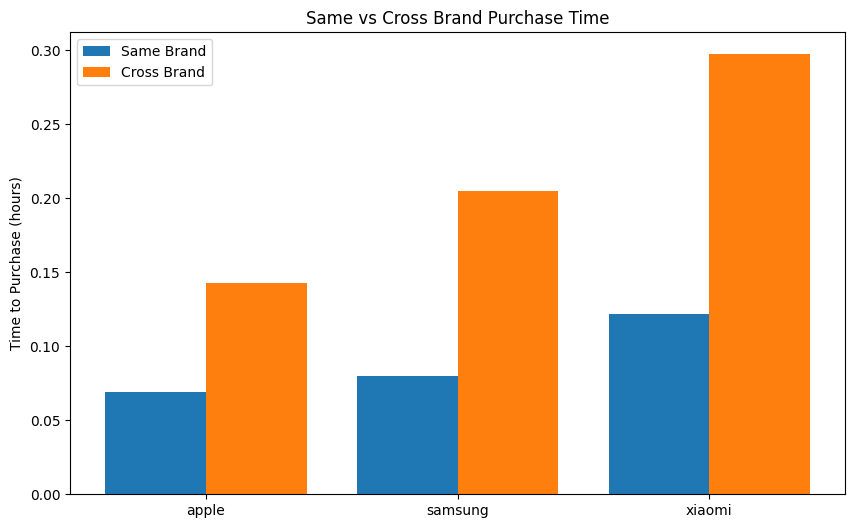

In [27]:
import matplotlib.pyplot as plt

x = range(len(compare_time_pivot))

plt.figure(figsize=(10,6))

plt.bar(
    [i - 0.2 for i in x],
    compare_time_pivot['same_brand_time'],
    width=0.4,
    label='Same Brand'
)

plt.bar(
    [i + 0.2 for i in x],
    compare_time_pivot['cross_purchase_time'],
    width=0.4,
    label='Cross Brand'
)

plt.xticks(x, compare_time_pivot['brand'])
plt.ylabel('Time to Purchase (hours)')
plt.title('Same vs Cross Brand Purchase Time')
plt.legend()

plt.show()